# CSCI 347 Final Project

Bailey Binando, Caitlin Hermanson, Lilly Pates

In [118]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import seaborn as sns

In [2]:
# load data
df = pd.read_csv("data/master_full_rolling_5day_features.csv")
df.head() # glimpse

,window_id,center_date,window_start,window_end,window_n_days,is_flood_event,n_flood_days_in_window,days_to_nearest_flood_in_window,flow_raw_max,flow_raw_mean,...,storm_wind_mean,RH2M_max,RH2M_mean,WS2M_max,WS2M_mean,storm_max_wind_kt_max,storm_max_wind_kt_mean,rp_for_impact,impact_proxy,impact_proxy_log
0,W000001,1975-01-04,1975-01-02,1975-01-06,5,0,0,NaN,50.0305,36.84938,...,0.0,NaN,NaN,NaN,NaN,0,0.0,3.198489,29791.041222,10.301997
1,W000002,1975-01-05,1975-01-03,1975-01-07,5,0,0,NaN,45.3183,34.26694,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.891200,28186.746623,10.246643
2,W000003,1975-01-06,1975-01-04,1975-01-08,5,0,0,NaN,45.3183,37.87166,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.891200,28186.746623,10.246643
3,W000004,1975-01-07,1975-01-05,1975-01-09,5,0,0,NaN,45.3183,38.02028,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.891200,28186.746623,10.246643
4,W000005,1975-01-08,1975-01-06,1975-01-10,5,0,0,NaN,42.1990,34.75174,...,0.0,NaN,NaN,NaN,NaN,0,0.0,2.692491,27107.964132,10.207620


## Feature Selection

In [3]:
# Correlation to impact for feature selection
# keep only numeric columns
num_df = df.select_dtypes(include = [np.number]).copy()

# drop rows with missing values for stable correlations
num_df = num_df.dropna()

# Spearman correlation with impact
corr_to_impact = (
    num_df.corr(method="spearman")["impact_proxy"].sort_values(ascending = False)
)

print(corr_to_impact)

impact_proxy_log                   1.000000
impact_proxy                       1.000000
rp_for_impact                      1.000000
rp_approx_max                      0.999928
flow_raw_max                       0.979499
flow_pct_max                       0.979499
max_exceedance_90                  0.979042
api_k_0_70_max                     0.964886
rain_2day_max                      0.936105
rain_3day_max                      0.919006
rp_approx_mean                     0.907794
api_k_0_80_max                     0.907667
rain_4day_max                      0.879679
tp_12h_intensity_mm_hr_max         0.868475
rain_1day_max                      0.863400
flow_raw_mean                      0.862610
api_k_0_85_max                     0.854213
rain_3day_mean                     0.852236
rain_2day_mean                     0.849658
tp_12h_intensity_mm_hr_mean        0.844644
api_k_0_70_mean                    0.832216
rain_5day_max                      0.826415
rain_4day_mean                  

In [4]:
# Variation correlation to each other 
num_df = df.select_dtypes(include=[np.number]).dropna()
corr = num_df.corr(method="spearman")

upper = corr.abs().where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = upper.stack().reset_index()
high_corr.columns = ["variable1", "variable2", "corr"]

high_corr = high_corr[high_corr["corr"] > 0.85]

# sort
high_corr = high_corr.sort_values("corr", ascending=False)

print(high_corr.to_string(index=False))

                 variable1                       variable2     corr
              impact_proxy                impact_proxy_log 1.000000
              flow_raw_max                    flow_pct_max 1.000000
           storm_wind_mean          storm_max_wind_kt_mean 1.000000
            storm_wind_max           storm_max_wind_kt_max 1.000000
             rp_for_impact                    impact_proxy 1.000000
             rp_for_impact                impact_proxy_log 1.000000
             rp_approx_max                    impact_proxy 0.999928
             rp_approx_max                   rp_for_impact 0.999928
             rp_approx_max                impact_proxy_log 0.999928
              flow_pct_max               max_exceedance_90 0.999436
              flow_raw_max               max_exceedance_90 0.999436
            rain_4day_mean                 api_k_0_70_mean 0.987587
           api_k_0_80_mean                 api_k_0_85_mean 0.986692
            api_k_0_80_max                  api_

In [5]:
# create month variable for future handling of missing values
df["month"] = pd.to_datetime(df["center_date"]).dt.month

# remove label/redundant analysis cols.
drop_cols = [
    "window_id", "center_date", "window_start", "window_end",
    "is_flood_event", "n_flood_days_in_window", "days_to_peak_flow",
    "days_to_nearest_flood_in_window", 'flow_raw_max',
    "impact_proxy", "impact_proxy_log", "rp_for_impact", 'rp_approx_max', 'rp_approx_mean',
    "window_n_days", "flow_raw_mean", "flow_pct_mean", "storm_wind_mean",
    "WS2M_mean", "RH2M_mean", 'api_k_0_70_max', 'api_k_0_70_mean', 'api_k_0_80_max',
    'api_k_0_80_mean', 'api_k_0_85_max', 'api_k_0_85_mean',
    "api_k_0_95_max", "api_k_0_95_mean", 'rain_1day_max', 'rain_1day_mean', 
    'rain_2day_max', 'rain_2day_mean', 'rain_4day_mean', 'rain_5day_max', 'rain_5day_mean', 'rain_7day_max',
    'rain_7day_mean', 'rain_14day_max', 'rain_14day_mean', 'tp_6h_intensity_mm_hr_mean',
    'tp_12h_intensity_mm_hr_max', 'tp_12h_intensity_mm_hr_mean', 'storm_max_wind_kt_max',
    'storm_max_wind_kt_mean', 'storm_within_300km', 'storm_within_500km', 'storm_wind_max',
    'max_exceedance_90', 'rain_4day_max', 'api_k_0_90_mean', 'rain_3day_mean'
]

feature_selection_final = df.drop(columns = drop_cols)

feature_selection_final.head()

,flow_pct_max,duration_above_90,area_above_90,rain_3day_max,tp_6h_intensity_mm_hr_max,api_k_0_90_max,storm_min_distance_km,RH2M_max,WS2M_max,month
0,0.687352,0,0.0,17.949861,1.387644,17.184730,NaN,NaN,NaN,1
1,0.654123,0,0.0,17.949861,1.387644,17.184730,NaN,NaN,NaN,1
2,0.654123,0,0.0,17.949861,1.387644,17.184730,NaN,NaN,NaN,1
3,0.654123,0,0.0,15.450961,0.169324,15.573230,NaN,NaN,NaN,1
4,0.628597,0,0.0,13.050195,0.169324,14.315296,NaN,NaN,NaN,1


## Preprocessing

In [6]:
# find NAs in dataset
feature_selection_final.isna().sum()


flow_pct_max                     0
duration_above_90                0
area_above_90                    0
rain_3day_max                    0
tp_6h_intensity_mm_hr_max        0
api_k_0_90_max                   0
storm_min_distance_km        12994
RH2M_max                      2187
WS2M_max                      2187
month                            0
dtype: int64

In [7]:
# FILL MISSING VALUES
D_raw = feature_selection_final.copy()

# fill missing meteoroligical values with monthly median
# original data from NASA starts in 1981
# monthly median to maintain seasonality
met_cols = [
    "RH2M_max", "WS2M_max"
]
for col in met_cols:
    D_raw[col] = D_raw[col].fillna(D_raw.groupby("month")[col].transform("median"))

# remove month col. (no longer needed)
D_raw = D_raw.drop(columns = "month")

# fill missing values in storm distance
# if there is no storm (hurricane/tropical cyclone) in the Atalantic coded as NA
# set NA distances to max distance + buffer
max_distance = D_raw["storm_min_distance_km"].max() # 13616.956 km
buffer = max_distance + 1000
D_raw["storm_min_distance_km"] = D_raw["storm_min_distance_km"].fillna(buffer) # fill missing
D_raw["no_storm"] = (D_raw["storm_min_distance_km"] > max_distance).astype(int)

# check
D_raw.isna().sum()

flow_pct_max                 0
duration_above_90            0
area_above_90                0
rain_3day_max                0
tp_6h_intensity_mm_hr_max    0
api_k_0_90_max               0
storm_min_distance_km        0
RH2M_max                     0
WS2M_max                     0
no_storm                     0
dtype: int64

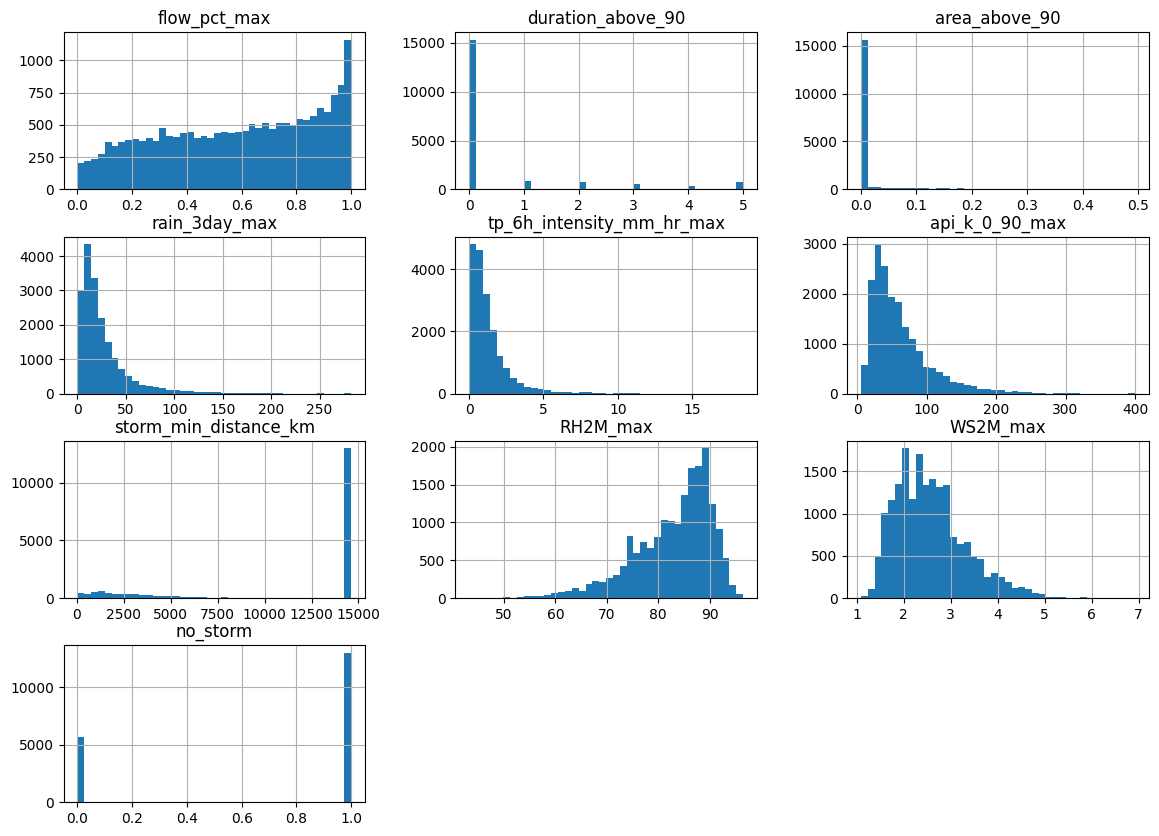

,flow_pct_max,duration_above_90,area_above_90,rain_3day_max,tp_6h_intensity_mm_hr_max,api_k_0_90_max,storm_min_distance_km,RH2M_max,WS2M_max
0,0.687352,0,0.0,2.941797,0.870307,2.900582,14616.956048,86.55,2.76
1,0.654123,0,0.0,2.941797,0.870307,2.900582,14616.956048,86.55,2.76
2,0.654123,0,0.0,2.941797,0.870307,2.900582,14616.956048,86.55,2.76
3,0.654123,0,0.0,2.800384,0.156425,2.807789,14616.956048,86.55,2.76
4,0.628597,0,0.0,2.642636,0.156425,2.728852,14616.956048,86.55,2.76


In [8]:
# TRANSFORMATIONS

# view distributions
D_raw.hist(figsize = (14, 10), bins = 40)
plt.show() # skewed: rain_3day_max, tp_6h_mm_hr_max, api_k_0_90_max, area_above_90

D = D_raw.copy()

D["rain_3day_max"] = np.log1p(D["rain_3day_max"])
D["tp_6h_intensity_mm_hr_max"] = np.log1p(D["tp_6h_intensity_mm_hr_max"])
D["api_k_0_90_max"] = np.log1p(D["api_k_0_90_max"])
D["area_above_90"] = np.log1p(D["area_above_90"])
D = D.drop(columns = "no_storm") # drop labeling variable
D.head()

## Analysis

### PCA

In [9]:
# standardize
scaler = StandardScaler()   
D_scaled = scaler.fit_transform(D)

# pca on normalized
pca_D_scaled = PCA() 
pca_transformed_D_scaled = pca_D_scaled.fit_transform(D_scaled)

# store component variance
explained_var = pca_D_scaled.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [10]:
# initialize
total_var = 0
count = 0

# iterate through components till 90% of variance is reached
while total_var < 0.90:
    total_var += explained_var[count]
    count += 1

print(f"In order to capture at least 90% of the variance, {count} principal components are needed.")
    

In order to capture at least 90% of the variance, 5 principal components are needed.


In [11]:
var_components_1_2 = explained_var[0] + explained_var[1]
print(f"The fraction of variance captured by PC1 and PC2 is {round(var_components_1_2, 4)}.")

The fraction of variance captured by PC1 and PC2 is 0.6889.


In [12]:
print(explained_var)

[0.53507213 0.15380512 0.09941002 0.07484773 0.06917547 0.03923456
 0.01669946 0.00732203 0.00443348]


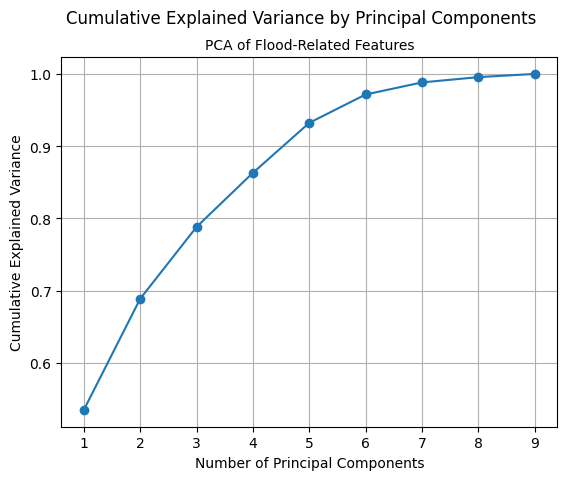

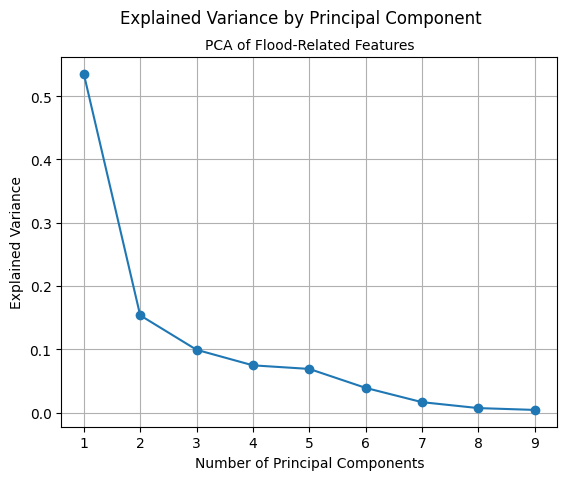

In [13]:
# PLOT CAPTURED VARIANCE FIGURES

# X axis: number of components (1 to n)
components = np.arange(1, len(cumulative_var) + 1)

# Plot
plt.plot(components, cumulative_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title("PCA of Flood-Related Features", fontsize = 10)
plt.suptitle('Cumulative Explained Variance by Principal Components')
plt.grid() # add gridlines

# Plot
plt.show()
plt.plot(components, explained_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
plt.suptitle('Explained Variance by Principal Component')
plt.title("PCA of Flood-Related Features", fontsize = 10)
plt.grid() # add gridlines

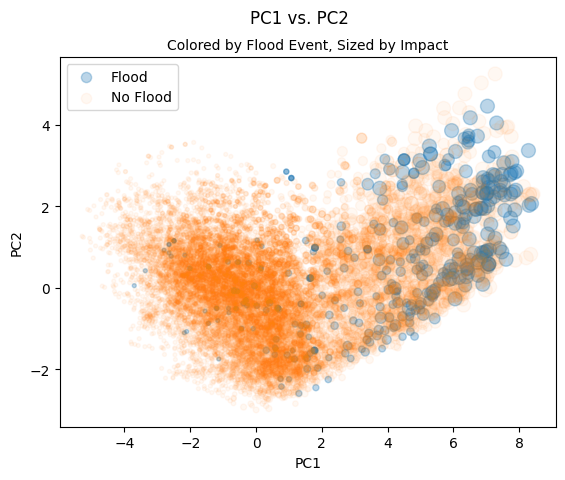

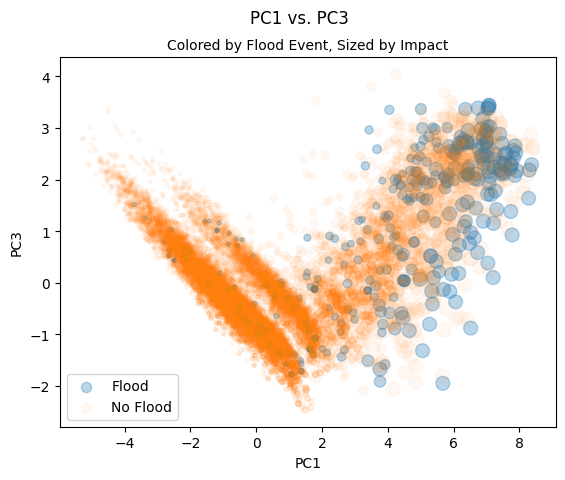

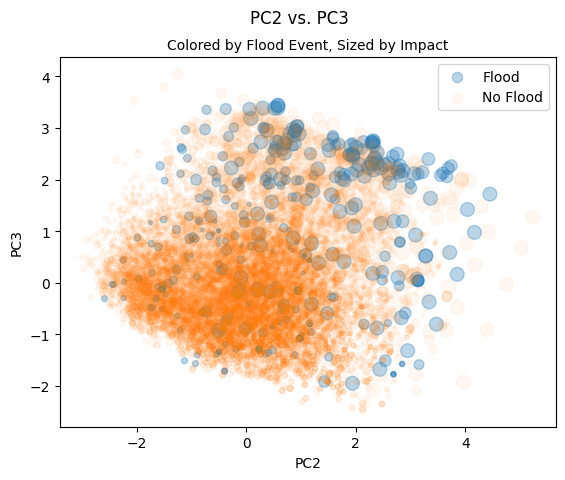

In [14]:
# PLOT PCA COMPONENTS
plot_df = D.copy()

# get label cols.
plot_df["no_storm"] = D_raw["no_storm"].values
plot_df["is_flood_event"] = df["is_flood_event"]
plot_df["impact_proxy"] = df["impact_proxy"]
sizes = (plot_df["impact_proxy"] / plot_df["impact_proxy"].max()) * 100 # normalize for extreme impacts

flood = plot_df["is_flood_event"] == 1 # color by flood/non-flood event
no_flood = plot_df["is_flood_event"] == 0

# PC1 vs. PC2
plt.scatter(pca_transformed_D_scaled[flood, 0], pca_transformed_D_scaled[flood, 1], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 0], pca_transformed_D_scaled[no_flood, 1], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC1 vs. PC2')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figure_pc1_2.png", dpi = 300, bbox_inches = "tight") # save as png

# PC1 vs. PC3
plt.show()
plt.scatter(pca_transformed_D_scaled[flood, 0], pca_transformed_D_scaled[flood, 2], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 0], pca_transformed_D_scaled[no_flood, 2], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC1 vs. PC3')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_pc1_3.png", dpi = 300, bbox_inches = "tight") # save as png

# PC2 vs. PC3
plt.show()
plt.scatter(pca_transformed_D_scaled[flood, 1], pca_transformed_D_scaled[flood, 2], alpha = 0.3, s = sizes[flood], label = "Flood")
plt.scatter(pca_transformed_D_scaled[no_flood, 1], pca_transformed_D_scaled[no_flood, 2], alpha = 0.05, s = sizes[no_flood], label = "No Flood")
plt.legend()
plt.suptitle('PC2 vs. PC3')
plt.title("Colored by Flood Event, Sized by Impact", fontsize = 10)
plt.xlabel("PC2")
plt.ylabel("PC3")

plt.savefig("figure_pc2_3.png", dpi=300, bbox_inches="tight") # save as png

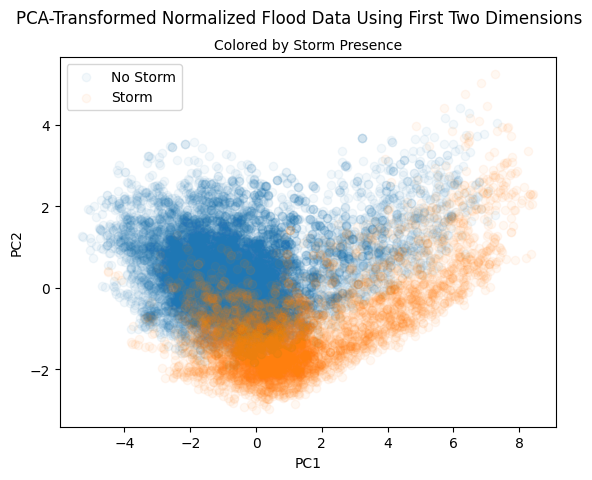

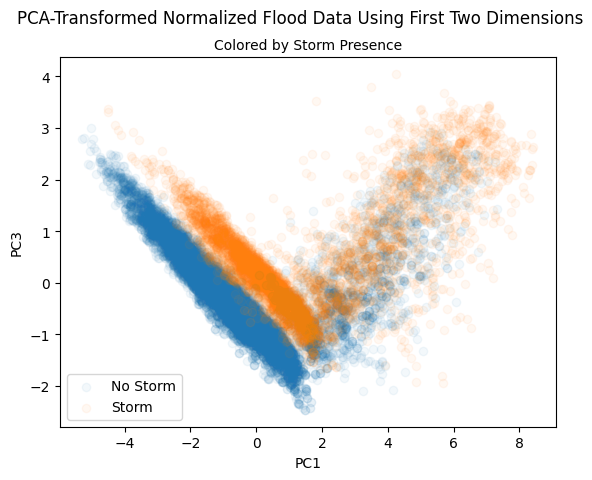

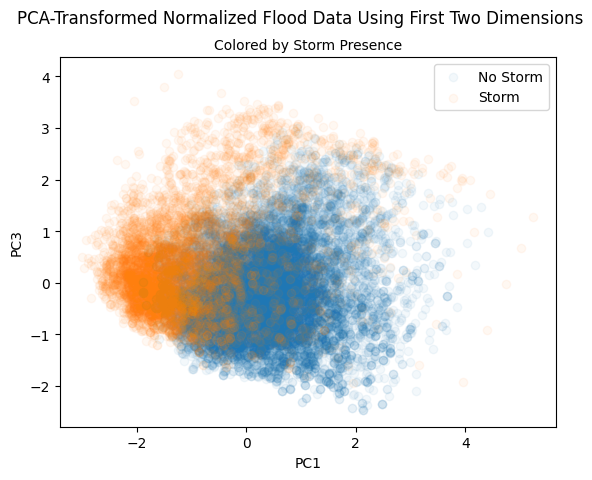

In [15]:
# PLOT PCA COMPONENTS
# Look at relationship w/ storm

# PC1 vs. PC2
plt.show()
no_storm = plot_df["no_storm"] == 1 # color by storm/no-storm presence
storm = plot_df["no_storm"] == 0
plt.scatter(pca_transformed_D_scaled[no_storm, 0], pca_transformed_D_scaled[no_storm, 1], alpha = 0.05, label = "No Storm")
plt.scatter(pca_transformed_D_scaled[storm, 0], pca_transformed_D_scaled[storm, 1], alpha = 0.05, label = "Storm")
plt.legend()
plt.suptitle('PCA-Transformed Normalized Flood Data Using First Two Dimensions')
plt.title("Colored by Storm Presence", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figure_pc1_2_storm.png", dpi = 300, bbox_inches = "tight") # save as png

# PC1 vs. PC3
plt.show()
no_storm = plot_df["no_storm"] == 1 # color by storm/no-storm presence
storm = plot_df["no_storm"] == 0
plt.scatter(pca_transformed_D_scaled[no_storm, 0], pca_transformed_D_scaled[no_storm, 2], alpha = 0.05, label = "No Storm")
plt.scatter(pca_transformed_D_scaled[storm, 0], pca_transformed_D_scaled[storm, 2], alpha = 0.05, label = "Storm")
plt.legend()
plt.suptitle('PCA-Transformed Normalized Flood Data Using First Two Dimensions')
plt.title("Colored by Storm Presence", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_pc1_3_storm.png", dpi = 300, bbox_inches = "tight") # save as png

# PC2 vs. PC3
plt.show()
no_storm = plot_df["no_storm"] == 1 # color by storm/no-storm presence
storm = plot_df["no_storm"] == 0
plt.scatter(pca_transformed_D_scaled[no_storm, 1], pca_transformed_D_scaled[no_storm, 2], alpha = 0.05, label = "No Storm")
plt.scatter(pca_transformed_D_scaled[storm, 1], pca_transformed_D_scaled[storm, 2], alpha = 0.05, label = "Storm")
plt.legend()
plt.suptitle('PCA-Transformed Normalized Flood Data Using First Two Dimensions')
plt.title("Colored by Storm Presence", fontsize = 10)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.savefig("figure_pc2_3_storm.png", dpi = 300, bbox_inches = "tight") # save as png

In [115]:
# show the top 5 features by absolute loading for each PC
# what each component represents physically
n_top = 5

pcs = ["PC1", "PC2", "PC3"]

for pc_idx, pc_name in enumerate(pcs):
    loadings = components_pca[pc_idx].abs().sort_values(ascending=False)
    print("----{}: Top {} features ---".format(pc_name, n_top))
    print(loadings.head(n_top).to_string())
    print()

----PC1: Top 5 features ---
api_k_0_90_max               0.415404
rain_3day_max                0.402185
flow_pct_max                 0.396186
tp_6h_intensity_mm_hr_max    0.372073
duration_above_90            0.367729

----PC2: Top 5 features ---
WS2M_max                     0.715396
storm_min_distance_km        0.473960
RH2M_max                     0.268764
area_above_90                0.224996
tp_6h_intensity_mm_hr_max    0.221478

----PC3: Top 5 features ---
area_above_90            0.528543
duration_above_90        0.509110
RH2M_max                 0.341594
storm_min_distance_km    0.312462
flow_pct_max             0.297785



## Clustering

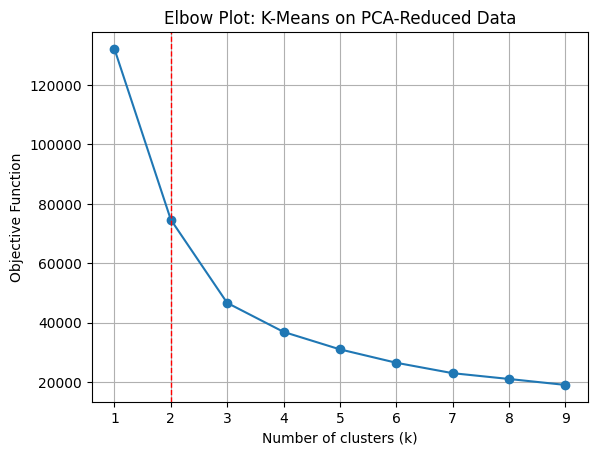

In [17]:
# Objective function value for each of the k value plot
# use first 3 PCs (~80% variance)
D_cluster = pca_transformed_D_scaled[:, :3] # PC1-5 minimal clustering benefit with added complexity
k_values = range(1, 10)
k_obj_pca = []

# iterate through each k-val
for k in k_values: 
    kmeans = KMeans(n_clusters = k, init = 'k-means++', n_init = 10) # run k-means algorithm
    kmeans.fit(D_cluster)
    k_obj_pca.append(kmeans.inertia_) # store
        

# plot elbow curve
plt.figure()
plt.plot(k_values, k_obj_pca, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Objective Function')
plt.title('Elbow Plot: K-Means on PCA-Reduced Data')
plt.grid()
plt.axvline(x = 2, linestyle = '--', linewidth = 1, color = "red") # add verticle line when k = 3
plt.savefig("figure_k_means_elbow.png", dpi = 300, bbox_inches = "tight") # save as png
plt.show() # elbow when k = 2

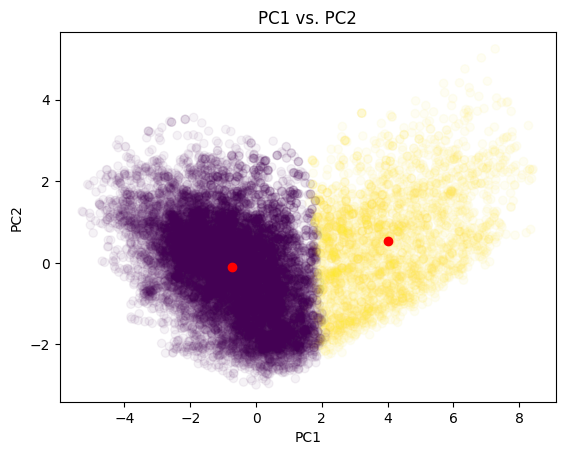

In [18]:
# Run k-means with k = 2
kmeans = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, random_state = 0) # run k-means algorithm
pred_cluster_labels = kmeans.fit_predict(D_cluster) # index of the cluster each sample belongs to
kmeans.cluster_centers_  # coordinates of cluster centers

# scatter plot of clusters & centroids
# PC1 vs. PC2
plt.scatter(D_cluster[:,0], D_cluster[:, 1], c=pred_cluster_labels, alpha = 0.05)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c = 'red')
plt.title("PC1 vs. PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("figure_k_means_clustering_pc1_2.png", dpi = 300, bbox_inches = "tight") # save as png


In [19]:
# Calc Silhoutte Score
# k = 3
sil_score = silhouette_score(D_cluster, pred_cluster_labels)
print("Silhoutte Score: k = 3")
print(sil_score)
print()

# compare to other cluster sizes
# Run k-means with k = 2
kmeans2 = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, random_state = 0) # run k-means algorithm
pred_cluster_labels2 = kmeans2.fit_predict(D_cluster) # index of the cluster each sample belongs to
kmeans2.cluster_centers_  # coordinates of cluster centers
sil_score2 = silhouette_score(D_cluster, pred_cluster_labels2)
print("Silhoutte Score: k = 2")
print(sil_score2)
print()

# Run k-means with k = 4
kmeans4 = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 300, random_state = 0) # run k-means algorithm
pred_cluster_labels4 = kmeans4.fit_predict(D_cluster) # index of the cluster each sample belongs to
kmeans4.cluster_centers_  # coordinates of cluster centers
sil_score4 = silhouette_score(D_cluster, pred_cluster_labels4)
print("Silhoutte Score: k = 4")
print(sil_score4)
print()

Silhoutte Score: k = 3
0.5144188859991242

Silhoutte Score: k = 2
0.5144188859991242

Silhoutte Score: k = 4
0.3533926615465901



Estimated number of clusters: 4
Estimated number of noise points: 98


Text(0, 0.5, 'PC2')

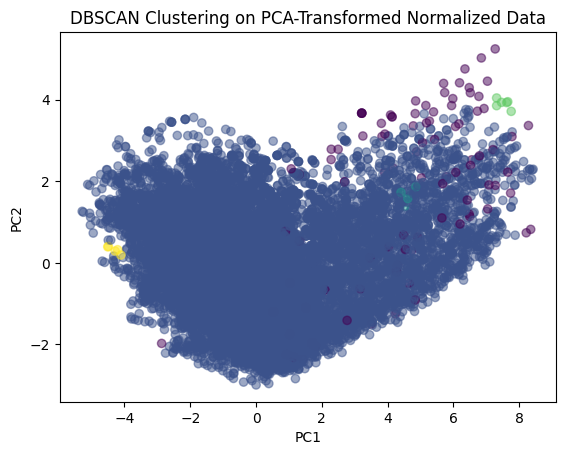

In [20]:
# DBSCAN
# run dbscan on pca transformed-normalized boston data
db = DBSCAN(eps = 0.5, min_samples = 5)
pred_labels = db.fit_predict(D_cluster)

# number of clusters in labels, ignoring noise if present
n_clusters_ = len(set(pred_labels)) - (1 if -1 in pred_labels else 0)
n_noise_ = list(pred_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_) # 3
print("Estimated number of noise points: %d" % n_noise_) # 23

# plot data
plt.scatter(D_cluster[:,0], D_cluster[:,1], c = pred_labels, alpha = 0.5)
plt.title("DBSCAN Clustering on PCA-Transformed Normalized Data")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Does not work well with continuous data

In [116]:
# profile each cluster by mean feature values in the original (untransformed) space
# this makes the cluster descriptions interpretable in real units
profile_df = D_raw.copy()
profile_df["cluster"] = pred_cluster_labels

cluster_profile = profile_df.groupby("cluster").mean().T
cluster_profile.columns = [f"Cluster {i+1}" for i in cluster_profile.columns]

# sort by cross-cluster variation to highlight the most distinguishing features
cluster_profile["variation"] = cluster_profile.std(axis=1)
cluster_profile = cluster_profile.sort_values("variation", ascending=False)

print("Feature means by cluster (sorted by cross-cluster variation):")
print(cluster_profile.drop(columns="variation").round(3).to_string())

Feature means by cluster (sorted by cross-cluster variation):
                           Cluster 1  Cluster 2
storm_min_distance_km      11630.659   7697.606
api_k_0_90_max                47.912    136.969
rain_3day_max                 17.641     76.628
RH2M_max                      81.891     88.692
duration_above_90              0.031      3.076
tp_6h_intensity_mm_hr_max      0.925      3.498
flow_pct_max                   0.513      0.963
no_storm                       0.746      0.432
WS2M_max                       2.528      2.789
area_above_90                  0.000      0.160


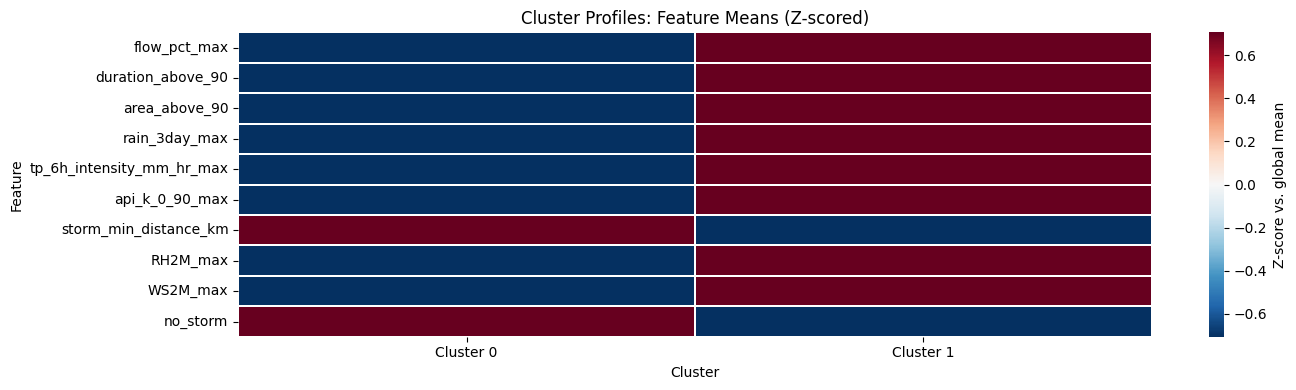

In [119]:
# heatmap of cluster profiles using z-scores so all features are on the same scale
# red = above average, blue = below average relative to global mean
profile_means = profile_df.groupby("cluster").mean()
profile_z = (profile_means - profile_means.mean()) / profile_means.std()
profile_z.index = "Cluster " + profile_z.index.astype(str)

plt.figure(figsize=(14, 4))
sns.heatmap(
    profile_z.T,
    cmap="RdBu_r",
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Z-score vs. global mean"}
)
plt.title("Cluster Profiles: Feature Means (Z-scored)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figure_cluster_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Trigger Evaluation

In [21]:
# add PCA scores and cluster labels to original dataset
analysis_df = df.copy()

analysis_df["PC1"] = pca_transformed_D_scaled[:, 0] # add PC1
analysis_df["PC2"] = pca_transformed_D_scaled[:, 1] # add PC2
analysis_df["PC3"] = pca_transformed_D_scaled[:, 2] # add PC3
analysis_df["cluster"] = pred_cluster_labels # add clusters

In [22]:
# Capstone Group Selected Trigger
# create binary trigger flags using rolling-window features

# Trigger 1: Flow & API (Compound/Balanced)
analysis_df["trigger1"] = ((analysis_df["flow_pct_max"] >= 0.96) & (analysis_df["api_k_0_95_max"].rank(pct=True) >= 0.90)).astype(int)

# Trigger 2: Flow OR API (OR Trigger)
analysis_df["trigger2"] = ((analysis_df["flow_pct_max"] >= 0.975) | (analysis_df["api_k_0_90_max"].rank(pct=True) >= 0.90)).astype(int)

In [111]:
# capstone (baseline) trigger
col = "trigger1"
case_col = col + "_case" # classify each row as TP/TN/FP/FN for each trigger type

analysis_df[case_col] = "TN" # assign everything as TN

# reassign labels
analysis_df.loc[(analysis_df[col] == 1) & (analysis_df["is_flood_event"] == 1), case_col] = "TP" 
analysis_df.loc[(analysis_df[col] == 1) & (analysis_df["is_flood_event"] == 0), case_col] = "FP"
analysis_df.loc[(analysis_df[col] == 0) & (analysis_df["is_flood_event"] == 1), case_col] = "FN"

# glimpse
analysis_df.head()


,window_id,center_date,window_start,window_end,window_n_days,is_flood_event,n_flood_days_in_window,days_to_nearest_flood_in_window,flow_raw_max,flow_raw_mean,...,trigger_tiered,trigger_score,trigger_score_flag,trigger_flow_0.97,trigger_flow_0.975,trigger_flow_0.98,trigger_flow_0.985,trigger_flow_0.99,trigger_flow_0.995,trigger_flow_0.995_case
0,W000001,1975-01-04,1975-01-02,1975-01-06,5,0,0,NaN,50.0305,36.84938,...,0,0.425187,0,0,0,0,0,0,0,TN
1,W000002,1975-01-05,1975-01-03,1975-01-07,5,0,0,NaN,45.3183,34.26694,...,0,0.408004,0,0,0,0,0,0,0,TN
2,W000003,1975-01-06,1975-01-04,1975-01-08,5,0,0,NaN,45.3183,37.87166,...,0,0.408004,0,0,0,0,0,0,0,TN
3,W000004,1975-01-07,1975-01-05,1975-01-09,5,0,0,NaN,45.3183,38.02028,...,0,0.388149,0,0,0,0,0,0,0,TN
4,W000005,1975-01-08,1975-01-06,1975-01-10,5,0,0,NaN,42.1990,34.75174,...,0,0.355193,0,0,0,0,0,0,0,TN


In [113]:
# Summary of trigger performance
# Confusion Matrix + Precision + Recall + F1 Score

summary = [] 
trigger = analysis_df[col]
flood = analysis_df["is_flood_event"]

# confusion matrix
tp = ((trigger == 1) & (flood == 1)).sum() # true positive
fp = ((trigger == 1) & (flood == 0)).sum() # false positive
fn = ((trigger == 0) & (flood == 1)).sum() # false negative
tn = ((trigger == 0) & (flood == 0)).sum() # true negative

# calc performance metrics
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = (2 * precision * recall) / (precision + recall)

# create summary table
summary.append({"trigger": col,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
                "precision": precision,
                "recall": recall,
                 "f1": f1})
summary_df = pd.DataFrame(summary)
print(summary_df)


    trigger   tp   fp   fn     tn  precision    recall        f1
0  trigger1  197  865  144  17417   0.185499  0.577713  0.280827


In [25]:
### Trigger Comparison (PCA)

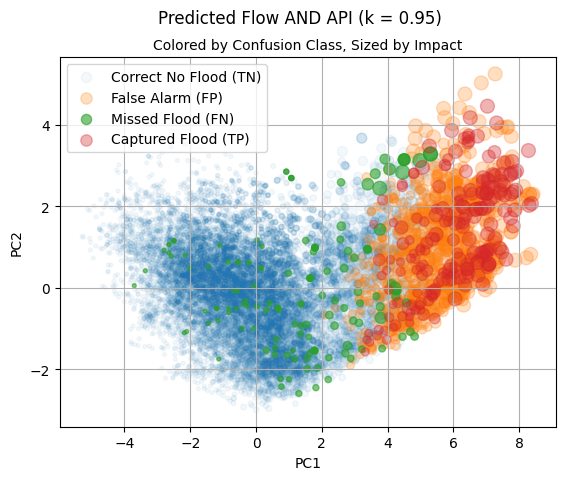

In [26]:
# Flow + API Trigger
case_col = "trigger1_case"

# normalize impact (prevent extreme vals.)
sizes_impact = (analysis_df["impact_proxy"] / analysis_df["impact_proxy"].max()) * 100

label_map = {
    "TN": "Correct No Flood (TN)",
    "FP": "False Alarm (FP)",
    "FN": "Missed Flood (FN)",
    "TP": "Captured Flood (TP)"
}

alpha_map = {
    "TN": 0.05,
    "FP": 0.25,
    "FN": 0.60,
    "TP": 0.35
}

plt.figure()

for case in ["TN", "FP", "FN", "TP"]:
    subset = analysis_df[analysis_df[case_col] == case]

    plt.scatter(subset["PC1"], subset["PC2"], s = sizes_impact[subset.index], alpha = alpha_map[case], label = label_map[case])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Predicted Flow AND API (k = 0.95)")
plt.title("Colored by Confusion Class, Sized by Impact", fontsize = 10)
plt.legend()
plt.grid()
plt.savefig("figure_pca_trig1_compariso .png", dpi = 300, bbox_inches = "tight") # save as png
plt.show()



In [ ]:
# trigger 2 (Flow OR API)
case_col = "trigger2_case"

for case in ["TN", "FP", "FN", "TP"]:
    subset = analysis_df[analysis_df[case_col] == case]
    plt.scatter(subset["PC1"], subset["PC2"], s = sizes_impact[subset.index], alpha = 0.15, label = case)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Predicted Flow OR API (k = 0.90)")
plt.title("Colored by Confusion Class, Sized by Impact", fontsize = 10)
plt.legend()
plt.grid()
plt.savefig("figure_pca_trig2_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

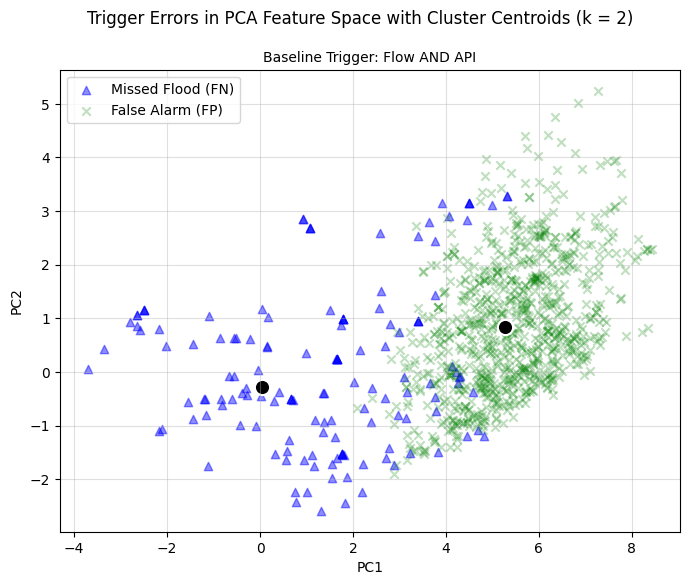

In [121]:
case_col = "trigger1_case"

# only select trigger 1 FP & FN
subset = analysis_df[analysis_df[case_col].isin(["FN", "FP"])].copy()

# create style mapping (want to color/label by errors, FN/FP)
color_map = {"FN": "blue", "FP": "green"}
marker_map = {"FN": "^", "FP": "x"}
alpha_map = {"FN": 0.45, "FP": 0.25}
label_map = {"FN": "Missed Flood (FN)", "FP": "False Alarm (FP)"}

plt.figure(figsize=(8, 6))

# iterate through trigger errors
for case in ["FN", "FP"]:
    data = subset[subset[case_col] == case]

    # plot error points
    plt.scatter(data["PC1"], data["PC2"], c = color_map[case], marker = marker_map[case], alpha = alpha_map[case], label = label_map[case]
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.suptitle("Trigger Errors in PCA Feature Space with Cluster Centroids (k = 2)")
plt.title("Baseline Trigger: Flow AND API", fontsize = 10)
plt.grid(alpha = 0.4)
plt.legend()

# add cluster centroids
centroids = subset.groupby("cluster")[["PC1", "PC2"]].mean() # calculate centroid for each cluster

plt.scatter(centroids["PC1"], centroids["PC2"], c = "black", s = 120, marker = "o", edgecolor = "white", linewidth = 1.5
)

plt.savefig("figure_pca_trigger_errors.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
# calc confusion matrix proportion in each cluster
trigger1_cluster = pd.crosstab(analysis_df["cluster"], analysis_df["trigger1_case"], normalize="index")
print(trigger1_cluster)


trigger1_case        FN        FP        TN        TP
cluster                                              
0              0.005649  0.000000  0.994351  0.000000
1              0.019170  0.301499  0.610666  0.068665


In [29]:
# summary of trigger outcomes
analysis_df.groupby("trigger1_case")["impact_proxy"].describe()

,count,mean,std,min,25%,50%,75%,max
trigger1_case,,,,,,,,
FN,144.0,69412.578018,59272.393879,23095.210633,31245.015368,56747.568273,79922.612599,287335.413966
FP,865.0,189339.408999,72436.195405,91941.128458,118621.106802,176344.551720,287335.413966,287335.413966
TN,17417.0,36065.776255,25374.804230,23095.210633,23095.210633,25353.391130,38387.471926,287335.413966
TP,197.0,221788.882404,70133.071951,96813.806990,156576.363305,247825.901943,287335.413966,287335.413966


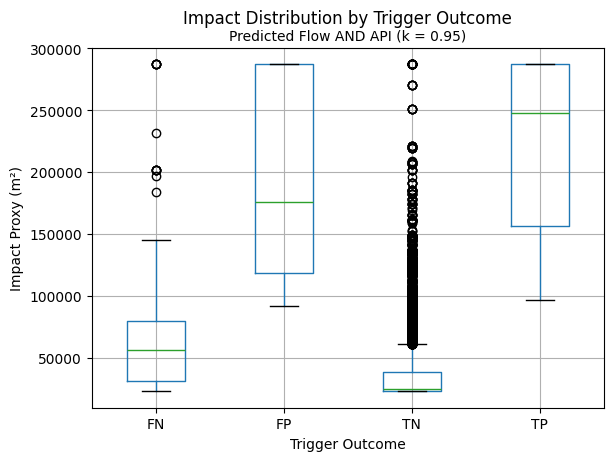

In [30]:
# boxplot of impact distribution
analysis_df.boxplot(column = "impact_proxy", by = "trigger1_case")

plt.suptitle("Impact Distribution by Trigger Outcome")
plt.title("Predicted Flow AND API (k = 0.95)", fontsize = 10)
plt.xlabel("Trigger Outcome")
plt.ylabel("Impact Proxy (m²)")
plt.savefig("figure_trigger1_impact.png", dpi = 300, bbox_inches = "tight") # save as png
plt.show()

In [31]:
# confusion matrix proportion in each cluster
analysis_df.groupby(["cluster", "trigger1_case"])["impact_proxy"].mean()

cluster  trigger1_case
0        FN                39199.837990
         TN                29510.726463
1        FN               118302.284611
         FP               189339.408999
         TN                94675.853303
         TP               221788.882404
Name: impact_proxy, dtype: float64

In [32]:
case_col = "trigger1_case"

fn_df = analysis_df[analysis_df[case_col] == "FN"]  # missed floods
fp_df = analysis_df[analysis_df[case_col] == "FP"]  # false alarms
tp_df = analysis_df[analysis_df[case_col] == "TP"]
tn_df = analysis_df[analysis_df[case_col] == "TN"]

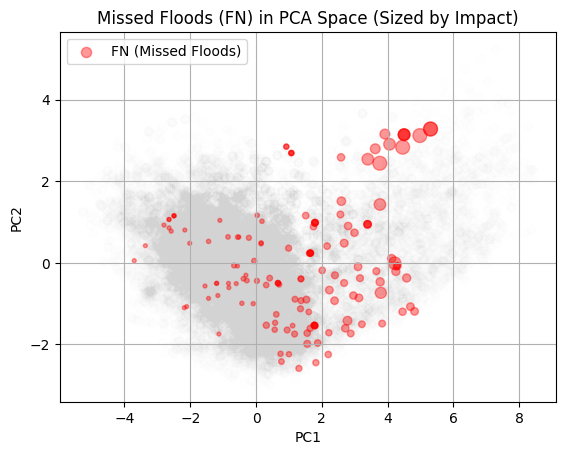

In [33]:
# Plot Trigger 1 missed floods
# Filter FN only
fn_df = analysis_df[analysis_df[case_col] == "FN"]

# Normalize sizes
sizes = (fn_df["impact_proxy"] / analysis_df["impact_proxy"].max()) * 100

# plot all points
plt.scatter(analysis_df["PC1"], analysis_df["PC2"], c = "lightgray", alpha = 0.01)
# FN points (highlighted + sized by impact)
plt.scatter(fn_df["PC1"], fn_df["PC2"], c = "red", s = sizes, alpha = 0.4, label = "FN (Missed Floods)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Missed Floods (FN) in PCA Space (Sized by Impact)")
plt.legend()
plt.grid()
plt.show()
# develop own eval metric - weight larger impacted events (weighted average/ratio) and compare to TP & TN


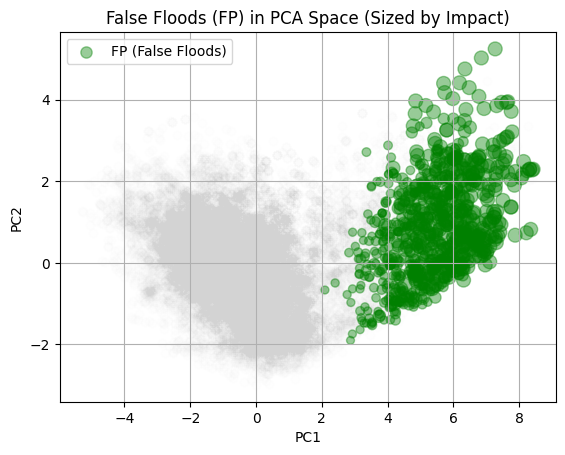

In [34]:
# Plot Trigger 1 false floods
# Normalize sizes
sizes = (fp_df["impact_proxy"] / analysis_df["impact_proxy"].max()) * 100

plt.figure()

# plot all points
plt.scatter(analysis_df["PC1"], analysis_df["PC2"], c = "lightgray", alpha = 0.01)
# FP points (highlighted + sized by impact)
plt.scatter(fp_df["PC1"], fp_df["PC2"], c = "green", s = sizes, alpha = 0.4, label = "FP (False Floods)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("False Floods (FP) in PCA Space (Sized by Impact)")
plt.legend()
plt.grid()
plt.show()

In [35]:
# create API percentile columns
analysis_df["api_k_0_90_pct"] = analysis_df["api_k_0_90_max"].rank(pct=True)
analysis_df["api_k_0_95_pct"] = analysis_df["api_k_0_95_max"].rank(pct=True)

# summarize confusion matrix for trigger1
analysis_df.groupby(case_col)[["flow_pct_max","api_k_0_95_pct", "PC1", "impact_proxy"]].mean()

,flow_pct_max,api_k_0_95_pct,PC1,impact_proxy
trigger1_case,,,,
FN,0.771458,0.688830,1.323975,69412.578018
FP,0.984729,0.957038,5.392504,189339.408999
TN,0.556581,0.470419,-0.346664,36065.776255
TP,0.989729,0.973042,6.003440,221788.882404


In [36]:
analysis_df.groupby(case_col)[["flow_pct_max","api_k_0_95_pct", "PC1", "impact_proxy"]].mean()

,flow_pct_max,api_k_0_95_pct,PC1,impact_proxy
trigger1_case,,,,
FN,0.771458,0.688830,1.323975,69412.578018
FP,0.984729,0.957038,5.392504,189339.408999
TN,0.556581,0.470419,-0.346664,36065.776255
TP,0.989729,0.973042,6.003440,221788.882404


## Kernel PCA

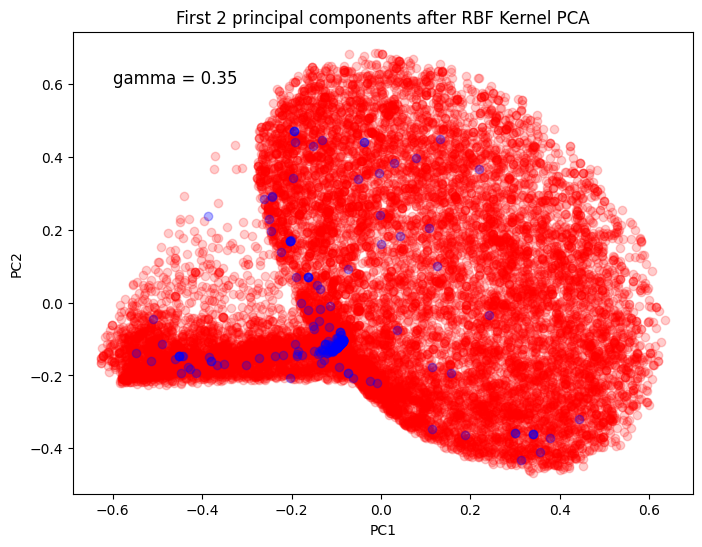

In [37]:

gamma_value = 0.35
y = df["is_flood_event"].values
kpca_rbf = KernelPCA(n_components=2, kernel="rbf", gamma=gamma_value)
X_kpca_rbf = kpca_rbf.fit_transform(D_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_kpca_rbf[y==0, 0], X_kpca_rbf[y==0, 1], color='red', alpha=0.2)
plt.scatter(X_kpca_rbf[y==1, 0], X_kpca_rbf[y==1, 1], color='blue', alpha=0.3)

plt.title('First 2 principal components after RBF Kernel PCA')
plt.text(-0.6, 0.6, f'gamma = {gamma_value}', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

#plt.figure(figsize=(8,6))
#plt.scatter(X_kpca_rbf[y==0, 0], X_kpca_rbf[y==0, 2], color='red', alpha=0.2)
#plt.scatter(X_kpca_rbf[y==1, 0], X_kpca_rbf[y==1, 2], color='blue', alpha=0.3)

#plt.title('First 2 principal components after RBF Kernel PCA')
#plt.text(-0.6, 0.6, f'gamma = {gamma_value}', fontsize=12)
#plt.xlabel('PC1')
#plt.ylabel('PC3')
#plt.show()

#plt.figure(figsize=(8,6))
#plt.scatter(X_kpca_rbf[y==0, 1], X_kpca_rbf[y==0, 2], color='red', alpha=0.2)
#plt.scatter(X_kpca_rbf[y==1, 1], X_kpca_rbf[y==1, 2], color='blue', alpha=0.3)

#plt.title('First 2 principal components after RBF Kernel PCA')
#plt.text(-0.6, 0.6, f'gamma = {gamma_value}', fontsize=12)
#plt.xlabel('PC2')
#plt.ylabel('PC3')
#plt.show()

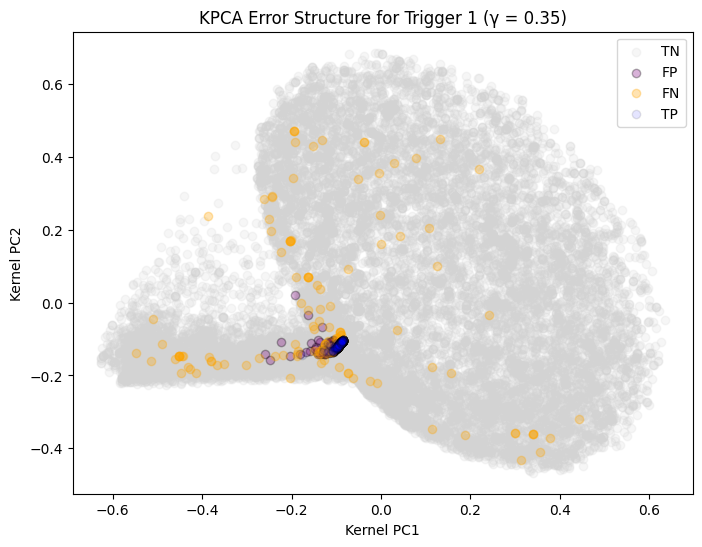

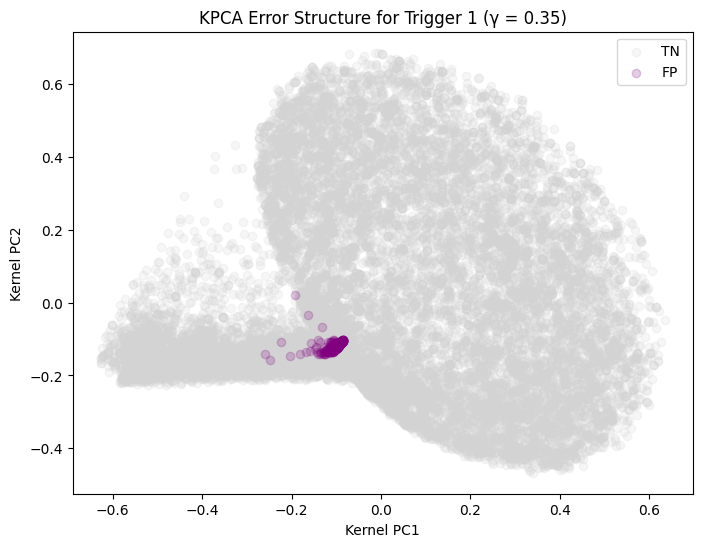

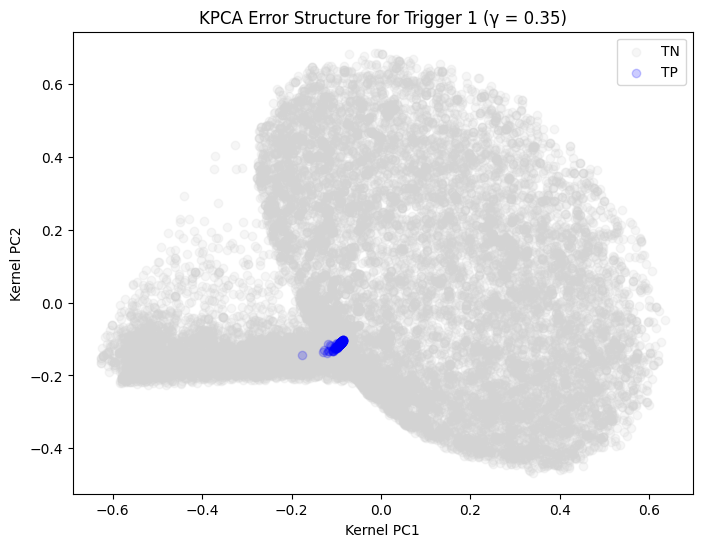

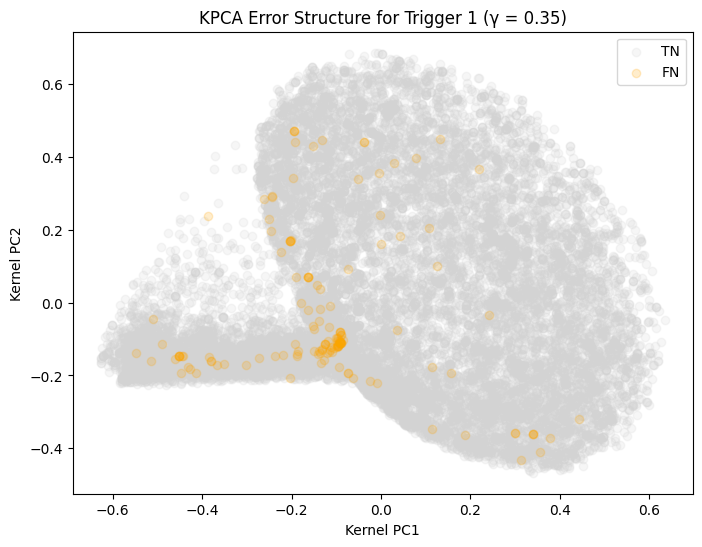

In [98]:

y_case = analysis_df["trigger1_case"].values 

kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.35)
X_kpca = kpca.fit_transform(D_scaled)

TN = y_case == "TN"
TP = y_case == "TP"
FP = y_case == "FP"
FN = y_case == "FN"

plt.figure(figsize=(8,6))

plt.scatter(X_kpca[TN, 0], X_kpca[TN, 1], color="lightgray", alpha=0.2, label="TN")
plt.scatter(X_kpca[FP, 0], X_kpca[FP, 1], color="purple", alpha=0.3, label="FP", edgecolors = "black")
plt.scatter(X_kpca[FN, 0], X_kpca[FN, 1], color="orange", alpha=0.3, label="FN")
plt.scatter(X_kpca[TP, 0], X_kpca[TP, 1], color="blue", alpha=0.1, label="TP", edgecolors = "black")

plt.title("KPCA Error Structure for Trigger 1 (γ = 0.35)")
plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))

plt.scatter(X_kpca[TN, 0], X_kpca[TN, 1], color="lightgray", alpha=0.2, label="TN")
#plt.scatter(X_kpca[TP, 0], X_kpca[TP, 1], color="blue", alpha=0.2, label="TP")
plt.scatter(X_kpca[FP, 0], X_kpca[FP, 1], color="purple", alpha=0.2, label="FP")
#plt.scatter(X_kpca[FN, 0], X_kpca[FN, 1], color="orange", alpha=0.1, label="FN")

plt.title("KPCA Error Structure for Trigger 1 (γ = 0.35)")
plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))

plt.scatter(X_kpca[TN, 0], X_kpca[TN, 1], color="lightgray", alpha=0.2, label="TN")
plt.scatter(X_kpca[TP, 0], X_kpca[TP, 1], color="blue", alpha=0.2, label="TP")
#plt.scatter(X_kpca[FP, 0], X_kpca[FP, 1], color="purple", alpha=0.2, label="FP")
#plt.scatter(X_kpca[FN, 0], X_kpca[FN, 1], color="orange", alpha=0.1, label="FN")

plt.title("KPCA Error Structure for Trigger 1 (γ = 0.35)")
plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))

plt.scatter(X_kpca[TN, 0], X_kpca[TN, 1], color="lightgray", alpha=0.2, label="TN")
#plt.scatter(X_kpca[TP, 0], X_kpca[TP, 1], color="blue", alpha=0.2, label="TP")
#plt.scatter(X_kpca[FP, 0], X_kpca[FP, 1], color="purple", alpha=0.2, label="FP")
plt.scatter(X_kpca[FN, 0], X_kpca[FN, 1], color="orange", alpha=0.2, label="FN")

plt.title("KPCA Error Structure for Trigger 1 (γ = 0.35)")
plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.legend()
plt.show()

In [102]:
region = (
    (X_kpca[:,0] > -0.3) & (X_kpca[:,0] < -0.1) &
    (X_kpca[:,1] > -0.2) & (X_kpca[:,1] < 0.05)
)

cols = [
    "flow_pct_max",
    "api_k_0_90_max",
    "rain_3day_max",
    "tp_6h_intensity_mm_hr_max"
]

print("FN in region")
print(analysis_df[FN & region][cols].describe())
print()

print("TP in region")
print(analysis_df[TP & region][cols].describe())

FN in region
       flow_pct_max  api_k_0_90_max  rain_3day_max  tp_6h_intensity_mm_hr_max
count     36.000000       36.000000      36.000000                  36.000000
mean       0.878236      116.033911      42.034553                   2.016298
std        0.174255       32.481850      20.707271                   1.162678
min        0.414430       40.028786       5.068123                   0.384906
25%        0.925878      111.254700      29.350088                   1.150522
50%        0.942747      121.929826      42.244780                   1.785043
75%        0.955564      133.434843      54.153952                   2.808789
max        0.988727      171.717606      77.915861                   4.787739

TP in region
       flow_pct_max  api_k_0_90_max  rain_3day_max  tp_6h_intensity_mm_hr_max
count     22.000000       22.000000      22.000000                  22.000000
mean       0.974293      148.850009      79.513481                   2.713054
std        0.009660       15.221601  

In [103]:
import numpy as np
import pandas as pd
from itertools import product

# ============================================================
# 1. SETUP
# ============================================================

label_col = "is_flood_event"
impact_col = "impact_proxy"

flow_col = "flow_pct_max"
api_raw_col = "api_k_0_90_max"
rain_raw_col = "rain_3day_max"

df = analysis_df.copy()

# Convert API and rain to percentile scale
df["api_pct"] = df[api_raw_col].rank(pct=True)
df["rain_pct"] = df[rain_raw_col].rank(pct=True)

api_col = "api_pct"
rain_col = "rain_pct"

required_cols = [label_col, impact_col, flow_col, api_col, rain_col]
df = df.dropna(subset=required_cols).copy()
df[label_col] = df[label_col].astype(int)

# ============================================================
# 2. EVALUATION FUNCTION
# ============================================================

def evaluate_trigger(y_true, y_pred, impact, rule_name):
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    impact = np.asarray(impact)

    tp = y_true & y_pred
    fp = ~y_true & y_pred
    fn = y_true & ~y_pred
    tn = ~y_true & ~y_pred

    TP, FP, FN, TN = tp.sum(), fp.sum(), fn.sum(), tn.sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else np.nan
    )

    total_flood_impact = impact[y_true].sum()
    captured_impact = impact[tp].sum()
    missed_impact = impact[fn].sum()
    false_alarm_impact = impact[fp].sum()

    pct_impact_captured = captured_impact / total_flood_impact
    pct_impact_missed = missed_impact / total_flood_impact

    # Custom impact-weighted score
    impact_score = (
        pct_impact_captured
        - 1.5 * pct_impact_missed
        - 0.25 * (false_alarm_impact / total_flood_impact)
    )

    return {
        "rule": rule_name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "captured_impact": captured_impact,
        "missed_impact": missed_impact,
        "false_alarm_impact": false_alarm_impact,
        "total_flood_impact": total_flood_impact,
        "pct_impact_captured": pct_impact_captured,
        "pct_impact_missed": pct_impact_missed,
        "impact_score": impact_score
    }

# ============================================================
# 3. BASELINE TRIGGER
# ============================================================

baseline_rule = (
    (df[flow_col] >= 0.960) &
    (df[api_col] >= 0.900)
)

baseline_eval = evaluate_trigger(
    y_true=df[label_col],
    y_pred=baseline_rule,
    impact=df[impact_col],
    rule_name="Baseline: Flow >= 0.960 AND API >= 0.900"
)

# ============================================================
# 4. TARGETED REFINEMENT GRIDS
# Based on FN region analysis:
# missed floods had lower/moderate flow + API than captured floods
# ============================================================

flow_grid = [0.940, 0.950, 0.955, 0.965]
api_grid = [0.900, 0.925, 0.950]
rain_grid = [0.850, 0.900, 0.925]
flow_override_grid = [0.985, 0.990]

results = [baseline_eval]

for f, a, r, override in product(flow_grid, api_grid, rain_grid, flow_override_grid):

    flow = df[flow_col] >= f
    api = df[api_col] >= a
    rain = df[rain_col] >= r
    flow_override = df[flow_col] >= override

    candidate_rules = {
        f"Flow >= {f:.3f} AND API >= {a:.3f}":
            flow & api,

        f"Flow >= {f:.3f} AND (API >= {a:.3f} OR Rain >= {r:.3f})":
            flow & (api | rain),

        f"(Flow >= {f:.3f} AND API >= {a:.3f}) OR Flow >= {override:.3f}":
            (flow & api) | flow_override,

        f"(Flow >= {f:.3f} AND (API >= {a:.3f} OR Rain >= {r:.3f})) OR Flow >= {override:.3f}":
            (flow & (api | rain)) | flow_override
    }

    for rule_name, pred in candidate_rules.items():
        results.append(
            evaluate_trigger(
                y_true=df[label_col],
                y_pred=pred,
                impact=df[impact_col],
                rule_name=rule_name
            )
        )

results_df = pd.DataFrame(results)

# Remove duplicate rules that produce same confusion matrix
results_df = results_df.drop_duplicates(
    subset=["TP", "FP", "FN", "TN", "captured_impact", "missed_impact", "false_alarm_impact"]
).copy()

# ============================================================
# 5. FILTER + RANK
# ============================================================

filtered = results_df[
    (results_df["recall"] >= 0.50) &
    (results_df["pct_impact_captured"] >= 0.80)
].copy()

best_rules = filtered.sort_values(
    by=["impact_score", "pct_impact_captured", "precision"],
    ascending=[False, False, False]
)

cols_to_show = [
    "rule",
    "TP", "FP", "FN",
    "precision", "recall", "f1",
    "pct_impact_captured",
    "pct_impact_missed",
    "false_alarm_impact",
    "impact_score"
]

best_rules[cols_to_show].head(20)

,rule,TP,FP,FN,precision,recall,f1,pct_impact_captured,pct_impact_missed,false_alarm_impact,impact_score
247,(Flow >= 0.965 AND API >= 0.925) OR Flow >= 0.990,203,873,138,0.188662,0.595308,0.286521,0.855994,0.144006,1.761493e+08,-0.180264
199,(Flow >= 0.955 AND API >= 0.950) OR Flow >= 0.990,190,739,151,0.204521,0.557185,0.299213,0.819300,0.180700,1.573544e+08,-0.184478
175,(Flow >= 0.955 AND API >= 0.925) OR Flow >= 0.990,211,968,130,0.178965,0.618768,0.277632,0.869586,0.130414,1.849469e+08,-0.187249
127,(Flow >= 0.950 AND API >= 0.950) OR Flow >= 0.990,191,758,150,0.201264,0.560117,0.296124,0.820883,0.179117,1.589505e+08,-0.187953
271,(Flow >= 0.965 AND API >= 0.950) OR Flow >= 0.990,184,699,157,0.208381,0.539589,0.300654,0.809344,0.190656,1.536424e+08,-0.192083
55,(Flow >= 0.940 AND API >= 0.950) OR Flow >= 0.990,192,783,149,0.196923,0.563050,0.291793,0.822377,0.177623,1.608880e+08,-0.193240
103,(Flow >= 0.950 AND API >= 0.925) OR Flow >= 0.990,213,1007,128,0.174590,0.624633,0.272902,0.872701,0.127299,1.882164e+08,-0.194687
31,(Flow >= 0.940 AND API >= 0.925) OR Flow >= 0.990,214,1063,127,0.167580,0.627566,0.264524,0.874195,0.125805,1.925216e+08,-0.211000
243,(Flow >= 0.965 AND API >= 0.925) OR Flow >= 0.985,204,928,137,0.180212,0.598240,0.276986,0.859422,0.140578,1.857101e+08,-0.216215
171,(Flow >= 0.955 AND API >= 0.925) OR Flow >= 0.985,212,1023,129,0.171660,0.621701,0.269036,0.873014,0.126986,1.945077e+08,-0.223200


In [104]:
# ============================================================
# IMPACT-FOCUSED SUMMARY TABLE
# ============================================================

summary_cols = [
    "rule",
    "TP", "FP", "FN",
    "precision", "recall", "f1",
    "captured_impact",
    "missed_impact",
    "false_alarm_impact",
    "pct_impact_captured",
    "pct_impact_missed"
]

impact_summary = results_df[summary_cols].copy()

# make readable
impact_summary["pct_impact_captured"] = impact_summary["pct_impact_captured"] * 100
impact_summary["pct_impact_missed"] = impact_summary["pct_impact_missed"] * 100

impact_summary = impact_summary.rename(columns={
    "captured_impact": "TP Impact",
    "missed_impact": "FN Impact",
    "false_alarm_impact": "FP Impact",
    "pct_impact_captured": "% Impact Captured",
    "pct_impact_missed": "% Impact Missed"
})

# rank by impact captured, then lower FP impact
impact_summary_sorted = impact_summary.sort_values(
    by=["% Impact Captured", "FP Impact"],
    ascending=[False, True]
)

impact_summary_sorted.head(20)

,rule,TP,FP,FN,precision,recall,f1,TP Impact,FN Impact,FP Impact,% Impact Captured,% Impact Missed
50,Flow >= 0.940 AND (API >= 0.950 OR Rain >= 0.850),234,1934,107,0.107934,0.686217,0.186528,4.900120e+07,4.686623e+06,2.833087e+08,91.270603,8.729397
26,Flow >= 0.940 AND (API >= 0.925 OR Rain >= 0.850),234,1975,107,0.105930,0.686217,0.183529,4.900120e+07,4.686623e+06,2.866615e+08,91.270603,8.729397
2,Flow >= 0.940 AND (API >= 0.900 OR Rain >= 0.850),234,1992,107,0.105121,0.686217,0.182314,4.900120e+07,4.686623e+06,2.881692e+08,91.270603,8.729397
10,Flow >= 0.940 AND (API >= 0.900 OR Rain >= 0.900),232,1806,109,0.113837,0.680352,0.195040,4.879685e+07,4.890972e+06,2.721486e+08,90.889978,9.110022
122,Flow >= 0.950 AND (API >= 0.950 OR Rain >= 0.850),231,1700,110,0.119627,0.677419,0.203345,4.876013e+07,4.927687e+06,2.651813e+08,90.821592,9.178408
98,Flow >= 0.950 AND (API >= 0.925 OR Rain >= 0.850),231,1720,110,0.118401,0.677419,0.201571,4.876013e+07,4.927687e+06,2.669285e+08,90.821592,9.178408
74,Flow >= 0.950 AND (API >= 0.900 OR Rain >= 0.850),231,1732,110,0.117677,0.677419,0.200521,4.876013e+07,4.927687e+06,2.680599e+08,90.821592,9.178408
18,Flow >= 0.940 AND (API >= 0.900 OR Rain >= 0.925),230,1622,111,0.124190,0.674487,0.209758,4.860866e+07,5.079164e+06,2.552626e+08,90.539448,9.460552
20,(Flow >= 0.940 AND (API >= 0.900 OR Rain >= 0....,230,1632,111,0.123523,0.674487,0.208806,4.860866e+07,5.079164e+06,2.569886e+08,90.539448,9.460552
82,Flow >= 0.950 AND (API >= 0.900 OR Rain >= 0.900),229,1619,112,0.123918,0.671554,0.209228,4.855578e+07,5.132037e+06,2.577195e+08,90.440967,9.559033


In [105]:
baseline_pred = (
    (df["flow_pct_max"] >= 0.96) &
    (df["api_pct"] >= 0.90)
)

fp_mask = (df[label_col] == 0) & (baseline_pred == 1)

baseline_fp_impact = df.loc[fp_mask, impact_col].sum()

baseline_fp_impact

np.float64(201532695.82603478)

In [108]:
baseline_pred = (
    (df["flow_pct_max"] >= 0.96) &
    (df["api_pct"] >= 0.90)
)

baseline_eval = evaluate_trigger(
    y_true=df["is_flood_event"],
    y_pred=baseline_pred,
    impact=df["impact_proxy"],
    rule_name="Baseline: Flow ≥ 0.96 AND API ≥ 0.90"
)

# append to results
results_df = pd.concat([pd.DataFrame([baseline_eval]), results_df], ignore_index=True)
results_df[results_df["rule"].str.contains("Baseline")]

,rule,TP,FP,FN,TN,precision,recall,f1,captured_impact,missed_impact,false_alarm_impact,total_flood_impact,pct_impact_captured,pct_impact_missed,impact_score
0,Baseline: Flow ≥ 0.96 AND API ≥ 0.90,209,1110,132,17172,0.158453,0.612903,0.251807,4.613842e+07,7.549396e+06,2.015327e+08,5.368782e+07,0.859383,0.140617,-0.289988
1,Baseline: Flow ≥ 0.96 AND API ≥ 0.90,209,1110,132,17172,0.158453,0.612903,0.251807,4.613842e+07,7.549396e+06,2.015327e+08,5.368782e+07,0.859383,0.140617,-0.289988
2,Baseline: Flow ≥ 0.96 AND API ≥ 0.90,209,1110,132,17172,0.158453,0.612903,0.251807,4.613842e+07,7.549396e+06,2.015327e+08,5.368782e+07,0.859383,0.140617,-0.289988
3,Baseline: Flow >= 0.960 AND API >= 0.900,209,1110,132,17172,0.158453,0.612903,0.251807,4.613842e+07,7.549396e+06,2.015327e+08,5.368782e+07,0.859383,0.140617,-0.289988


In [114]:
# Which cluster's features explain trigger FNs best?
# Compare FN mean feature profile vs. overall cluster mean
fn_idx = analysis_df[analysis_df["trigger1_case"] == "FN"].index
fn_profile = D_raw.loc[fn_idx].mean()

tp_idx = analysis_df[analysis_df["trigger1_case"] == "TP"].index
tp_profile = D_raw.loc[tp_idx].mean()

comparison = pd.DataFrame({
    "FN": fn_profile,
    "TP": tp_profile,
}).T

# Show top distinguishing features
diff = (comparison.loc["TP"] - comparison.loc["FN"]).abs()
top_diff_cols = diff.sort_values(ascending=False).head(8).index

print("Features where TP and FN differ most:")
print(comparison[top_diff_cols].round(3).to_string())

Features where TP and FN differ most:
    storm_min_distance_km  api_k_0_90_max  rain_3day_max  RH2M_max  duration_above_90  tp_6h_intensity_mm_hr_max  WS2M_max  no_storm
FN               9621.576          89.505         37.810    84.372              1.097                      2.220     2.673     0.604
TP               4163.017         198.842        124.391    91.630              4.310                      4.624     3.352     0.178
